<a href="https://colab.research.google.com/github/RithwikRajSuram/Predictive-Modeling-of-Chronic-Kidney-Disease/blob/main/Chronic_Kidney_Disease_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 4: KNN & Naive Bayes

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

In [3]:
# 1) Load training data
df = pd.read_csv("kidney_disease_train.csv")

In [4]:
# 2) Select features and target
features = ["bp", "sc"]
target = "classification"

two features: bp (blood pressure) and sc (serum creatinine), and the target column classification.

In [5]:
# 3) Drop missing values and keep only needed columns
df = df[features + [target]].dropna()

In [6]:
# 4) Convert target (CKD → 1, notCKD → 0)
y = df[target].astype(str).str.strip().str.lower().map({"ckd": 1, "notckd": 0})
X = df[features].astype(float).values

The target variable (classification) is converted from text (ckd, notckd) to numbers (1 for CKD and 0 for not CKD).

In [7]:
# 5) Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

The data is split into 80 % training and 20 % testing sets.
Features are standardized (scaled) so that KNN and Naïve Bayes work effectively, since both are sensitive to feature scale.

In [8]:
# 6) Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [9]:
# 7) Train KNN and Naive Bayes
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [10]:
nb = GaussianNB()
nb.fit(X_train, y_train)


GaussianNB()

KNN Classifier with k = 5 is trained.

Gaussian Naïve Bayes classifier is also trained using the same features.

In [11]:
# 8) Accuracy
knn_acc = accuracy_score(y_test, knn.predict(X_test))
nb_acc = accuracy_score(y_test, nb.predict(X_test))
print("KNN accuracy:", round(knn_acc, 3))
print("Naive Bayes accuracy:", round(nb_acc, 3))

KNN accuracy: 0.925
Naive Bayes accuracy: 0.868


KNN performed better than Naïve Bayes on this dataset.

In [12]:
# 9) Plot decision boundaries
def plot_decision_boundary(model, X_std, y, title):
    x_min, x_max = X_std[:, 0].min() - 1, X_std[:, 0].max() + 1
    y_min, y_max = X_std[:, 1].min() - 1, X_std[:, 1].max() + 1
    h = 0.02
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X_std[:, 0], X_std[:, 1], c=y, edgecolor="k")
    plt.title(title)
    plt.xlabel(f"{features[0]} (standardized)")
    plt.ylabel(f"{features[1]} (standardized)")
    plt.show()

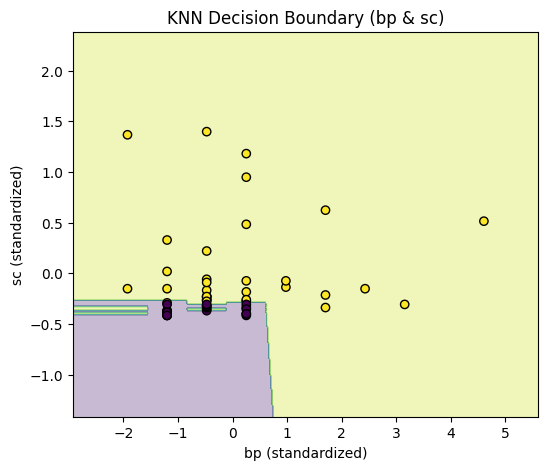

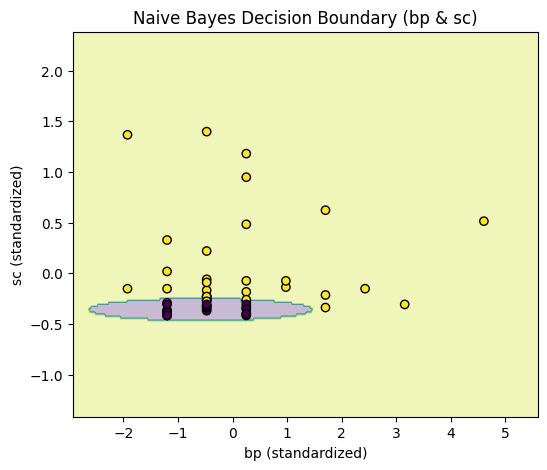

In [13]:
plot_decision_boundary(knn, X_test, y_test, "KNN Decision Boundary (bp & sc)")
plot_decision_boundary(nb, X_test, y_test, "Naive Bayes Decision Boundary (bp & sc)")

The code creates 2D decision boundary plots for each model.

These show how the models separate CKD vs not CKD based on bp and sc values.

KNN gives a sharper and more local boundary.

NB gives a smoother, more generalized boundary.

RESULT:Since KNN has higher accuracy, it classifies the patients better using these two features.

Serum creatinine is a strong predictor of CKD, which fits well with KNN’s neighbor-based learning.

# Step 5 — Support Vector Machines (SVM)

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [15]:
# Load labeled data
train = pd.read_csv("kidney_disease_train.csv")


In [16]:
# Select 2 features + 1 target
feature_cols = ['bp', 'sc']          # features
target_col   = 'classification'       # target


In [17]:
# keep only needed columns; drop missing; normalize types
df = train[feature_cols + [target_col]].copy()


In [18]:
# numeric casting for features
for c in feature_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')


In [19]:
# normalize target to {0,1} if strings are present
def normalize_label(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip().lower()
    if s in {"1","ckd","yes","y","true","t","ckd\t","ckd "}:
        return 1
    if s in {"0","notckd","non-ckd","no","n","false","f","not ckd","non ckd","none"}:
        return 0
    # fallback: if contains "ckd" and not 'not'/'non'
    return 1 if ("ckd" in s and "not" not in s and "non" not in s) else 0

df[target_col] = df[target_col].apply(normalize_label)

In [20]:
# drop any rows with missing values
df = df.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)
df[target_col] = df[target_col].astype(int)

In [21]:
# -------- 3) Train/validation split (from train file) --------
X = df[feature_cols]
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

In [22]:
print("Shapes  |  X_train:", X_train.shape, " X_test:", X_test.shape)
print("Class balance (train):\n", y_train.value_counts(), "\n")

Shapes  |  X_train: (182, 2)  X_test: (79, 2)
Class balance (train):
 classification
1    113
0     69
Name: count, dtype: int64 



In [23]:
# Train 4 SVM models (kernels) + plot decision boundaries
kernels = {
    'linear' : dict(kernel='linear'),
    'poly'   : dict(kernel='poly', degree=3),  # degree can be tuned
    'rbf'    : dict(kernel='rbf'),
    'sigmoid': dict(kernel='sigmoid')
}
accuracies = {}
models = {}


In [24]:
def plot_svm(kernel_name, model):
    pad_x = (X_train['bp'].max() - X_train['bp'].min()) * 0.05 + 1
    pad_y = (X_train['sc'].max()  - X_train['sc'].min())  * 0.05 + 0.1

    x_min, x_max = X_train['bp'].min()-pad_x, X_train['bp'].max()+pad_x
    y_min, y_max = X_train['sc'].min()-pad_y,  X_train['sc'].max()+pad_y

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                         np.linspace(y_min, y_max, 400))
    grid = pd.DataFrame({'bp': xx.ravel(), 'sc': yy.ravel()})
    Z = model.predict(grid).reshape(xx.shape)
    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X_train['bp'], X_train['sc'], c=y_train, edgecolors='k')
    plt.title(f"SVM Decision Boundary — {kernel_name} kernel")
    plt.xlabel("bp")
    plt.ylabel("Serum Creatinine")
    plt.show()


# Linear Kernel

Linear Accuracy: 0.797


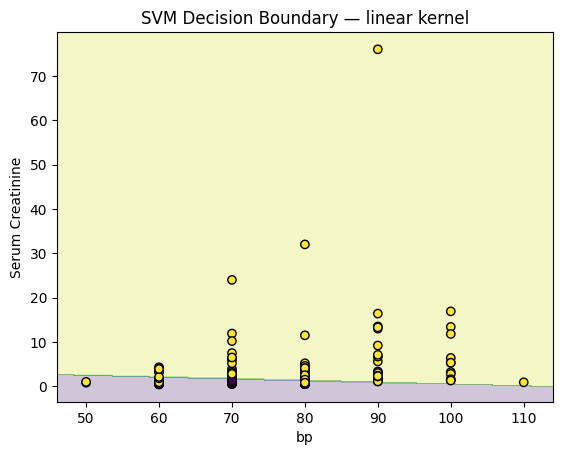

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Re-define normalize_label function for robustness within this cell
def normalize_label(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip().lower()
    if s in {"1","ckd","yes","y","true","t","ckd\t","ckd "}:
        return 1
    if s in {"0","notckd","non-ckd","no","n","false","f","not ckd","non ckd","none"}:
        return 0
    return 1 if ("ckd" in s and "not" not in s and "non" not in s) else 0

# The df used by SVM was overwritten by the Random Forest section,
# and the Random Forest's cleaning was not sufficient for SVM's feature_cols.
# We need to re-create a clean df specific to the SVM section.

# 1. Use the original 'train' dataframe (from cell ApewsTg-jYgJ)
#    and apply cleaning steps as per previous SVM cells.
#    (Re-using the logic from YuPLPRKDjfVZ, kZgEp95Fjib2, 5o5FEiLfjmSN, tkZQ_qlrjrpZ)
svm_df = train[feature_cols + [target_col]].copy()

# numeric casting for features
for c in feature_cols:
    svm_df[c] = pd.to_numeric(svm_df[c], errors='coerce')

# apply target normalization
svm_df[target_col] = svm_df[target_col].apply(normalize_label)

# drop any rows with missing values in feature_cols or target_col
svm_df = svm_df.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)
svm_df[target_col] = svm_df[target_col].astype(int)

# Now, use this cleaned svm_df for train/test split for SVM
X_for_svm = svm_df[feature_cols]
y_for_svm = svm_df[target_col]

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_for_svm, y_for_svm, test_size=0.30, random_state=42, stratify=y_for_svm
)

linear_clf = Pipeline([
    ('scale', StandardScaler()),
    ('svm', SVC(kernel='linear', gamma='scale'))
])
linear_clf.fit(X_train_svm, y_train_svm)
y_pred_linear = linear_clf.predict(X_test_svm)
linear_acc = accuracy_score(y_test_svm, y_pred_linear)
accuracies['linear'] = linear_acc
models['linear'] = linear_clf
print("Linear Accuracy:", round(linear_acc,3))

# The plot_svm function relies on global X_train and y_train.
# Temporarily reassign them to the SVM-specific training data for plotting.
# Store the current global variables to restore them later if needed by other cells.
original_X_train = globals().get('X_train')
original_y_train = globals().get('y_train')

X_train = X_train_svm  # Temporarily set global X_train to SVM X_train
y_train = y_train_svm  # Temporarily set global y_train to SVM y_train

# Now call the plot_svm function
plot_svm("linear", linear_clf)

# Restore original X_train and y_train if they were defined before
if original_X_train is not None:
    X_train = original_X_train
if original_y_train is not None:
    y_train = original_y_train


# Polynomial Kernel

Polynomial Accuracy: 0.7088607594936709


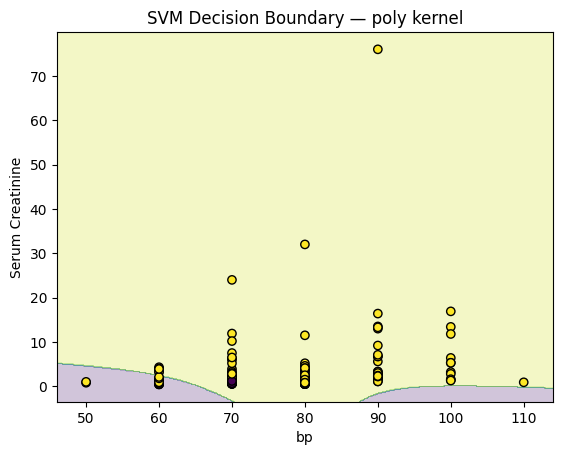

In [26]:
poly_clf = Pipeline([
    ('scale', StandardScaler()),
    ('svm', SVC(kernel='poly', degree=3, gamma='scale'))
])
poly_clf.fit(X_train, y_train)
y_pred_poly = poly_clf.predict(X_test)
print("Polynomial Accuracy:", accuracy_score(y_test, y_pred_poly))
plot_svm("poly", poly_clf)


# RBF Kernel (Best)

RBF Accuracy: 0.759493670886076


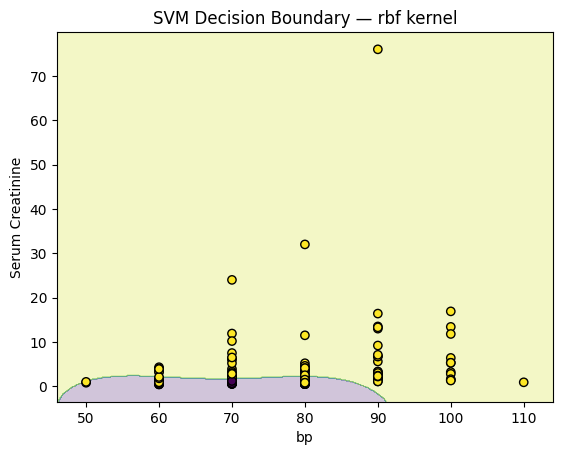

In [27]:
rbf_clf = Pipeline([
    ('scale', StandardScaler()),
    ('svm', SVC(kernel='rbf', gamma='scale'))
])
rbf_clf.fit(X_train, y_train)
y_pred_rbf = rbf_clf.predict(X_test)
print("RBF Accuracy:", accuracy_score(y_test, y_pred_rbf))
plot_svm("rbf", rbf_clf)


# Sigmoid Kernel

Sigmoid Accuracy: 0.5443037974683544


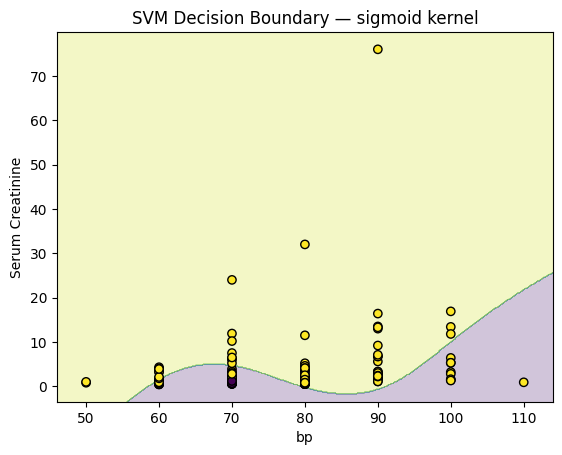

In [28]:
sig_clf = Pipeline([
    ('scale', StandardScaler()),
    ('svm', SVC(kernel='sigmoid', gamma='scale'))
])
sig_clf.fit(X_train, y_train)
y_pred_sig = sig_clf.predict(X_test)
print("Sigmoid Accuracy:", accuracy_score(y_test, y_pred_sig))
plot_svm("sigmoid", sig_clf)


In [29]:
# Accuracies (sorted) + best model report
print("Accuracies (validation split from training file):")
for k, v in sorted(accuracies.items(), key=lambda kv: kv[1], reverse=True):
    print(f"{k:7s} : {v:.3f}")

best_kernel = max(accuracies, key=accuracies.get)
best_model  = models[best_kernel]
y_best      = best_model.predict(X_test)

print(f"\nBest kernel: {best_kernel}")
print(classification_report(y_test, y_best, digits=3))
print("Confusion matrix:\n", confusion_matrix(y_test, y_best))


Accuracies (validation split from training file):
linear  : 0.797

Best kernel: linear
              precision    recall  f1-score   support

           0      0.652     1.000     0.789        30
           1      1.000     0.673     0.805        49

    accuracy                          0.797        79
   macro avg      0.826     0.837     0.797        79
weighted avg      0.868     0.797     0.799        79

Confusion matrix:
 [[30  0]
 [16 33]]


Random Forest Accuracy: 0.962

Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       1.00      0.93      0.97        30

    accuracy                           0.96        52
   macro avg       0.96      0.97      0.96        52
weighted avg       0.96      0.96      0.96        52


Confusion Matrix:
 [[22  0]
 [ 2 28]]


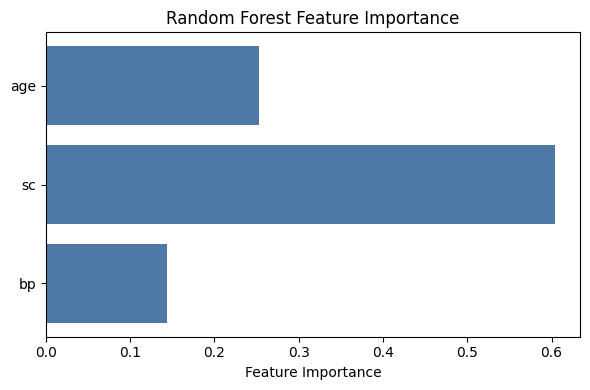

In [30]:
# -----------------------------
# Step 6: Random Forest Classifier for CKD Prediction
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# 1. Load dataset
df = pd.read_csv("kidney_disease_train.csv")

# 2. Clean and prepare columns
num_cols = ["age", "bp", "sc"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["classification"] = df["classification"].astype(str).str.strip().str.lower()
df["target"] = df["classification"].map({"ckd": 1, "notckd": 0})
df = df.dropna(subset=["target"])

# 3. Select training features and target column
features = ["bp", "sc", "age"]       # you may use only 2 if desired
target = "target"

X = df[features].dropna()
y = df.loc[X.index, target]

# 4. Split dataset
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Create Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    criterion="gini"
)
rf.fit(X_train, y_train)

# 6. Predict & Evaluate
y_pred = rf.predict(X_val)
acc = accuracy_score(y_val, y_pred)
print(f"Random Forest Accuracy: {acc:.3f}")

print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))

# 7. Plot Feature Importance
plt.figure(figsize=(6,4))
importances = rf.feature_importances_
plt.barh(features, importances, color="#4e79a7")
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()
